In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


# Import Required Libraries

In [3]:
# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing & Utilities
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

# Baseline Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Ensemble Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Clustering
from sklearn.cluster import KMeans, DBSCAN

# Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    silhouette_score
)

print("All libraries imported successfully.")


All libraries imported successfully.


# Loading the Dataset

In [4]:
df = pd.read_csv('/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv')
print(f"Dataset loaded: {df.shape[0]} customer profiles x {df.shape[1]} features")
print(f"Columns: {df.columns.tolist()}")
df.head(10)


Dataset loaded: 167 customer profiles x 10 features
Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


# EDA

In [5]:
rows, cols = df.shape
print(f"Rows (Customers): {rows}  |  Columns (Features): {cols}")
print("\nFeature names:", df.columns.tolist())
print("\nSample country names:", df['country'].head(5).tolist())


Rows (Customers): 167  |  Columns (Features): 10

Feature names: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

Sample country names: ['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Antigua and Barbuda']


In [6]:
df.info()
print("\nMemory usage:", df.memory_usage(deep=True).sum(), "bytes")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB

Memory usage: 21733 bytes


In [7]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

total_missing = df.isnull().sum().sum()
total_dupes   = df.duplicated().sum()
if total_missing == 0 and total_dupes == 0:
    print("\nData quality check passed. No missing values or duplicates found.")
else:
    print(f"\nIssues found: {total_missing} missing values, {total_dupes} duplicate rows.")


Missing values per column:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Duplicate rows: 0

Data quality check passed. No missing values or duplicates found.


In [8]:
summary = df.describe().round(2)
print("Statistical summary of all numeric features:")
print(summary.to_string())


Statistical summary of all numeric features:
       child_mort  exports  health  imports     income  inflation  life_expec  total_fer       gdpp
count      167.00   167.00  167.00   167.00     167.00     167.00      167.00     167.00     167.00
mean        38.27    41.11    6.82    46.89   17144.69       7.78       70.56       2.95   12964.16
std         40.33    27.41    2.75    24.21   19278.07      10.57        8.89       1.51   18328.70
min          2.60     0.11    1.81     0.07     609.00      -4.21       32.10       1.15     231.00
25%          8.25    23.80    4.92    30.20    3355.00       1.81       65.30       1.80    1330.00
50%         19.30    35.00    6.32    43.30    9960.00       5.39       73.10       2.41    4660.00
75%         62.10    51.35    8.60    58.75   22800.00      10.75       76.80       3.88   14050.00
max        208.00   200.00   17.90   174.00  125000.00     104.00       82.80       7.49  105000.00


# Correlation Heatmap

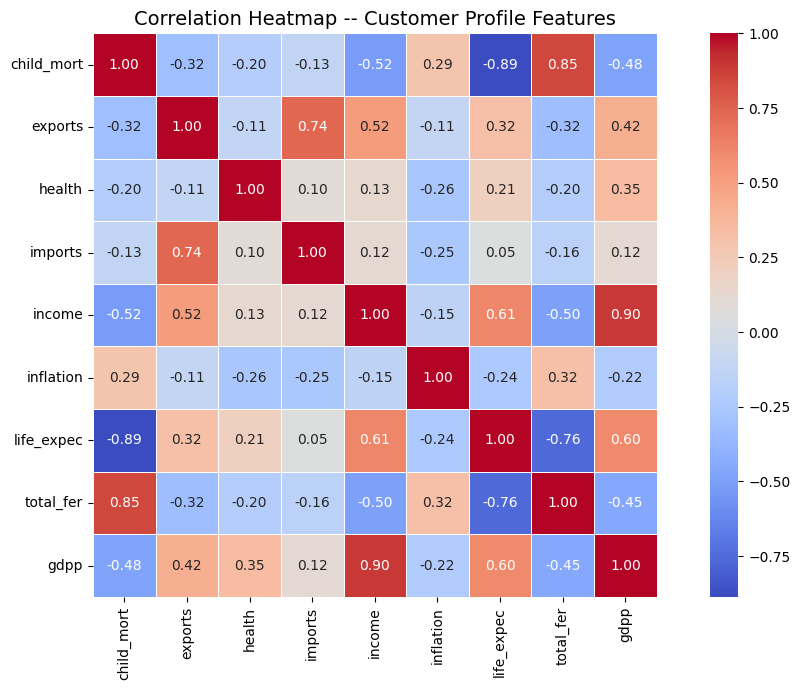


Key Correlation Findings:
  income  <-> gdpp         : Strong positive  -- high-income countries also have high GDP
  child_mort <-> life_expec: Strong negative  -- high mortality linked to shorter lifespan
  total_fer  <-> income    : Negative         -- affluent profiles show lower fertility
  health     <-> income    : Moderate positive -- wealthier profiles invest more in health



In [10]:
numeric_df = df.drop('country', axis=1)

plt.figure(figsize=(11, 7))
sns.heatmap(
    numeric_df.corr(),
    annot=True, fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5,
    square=True
)
plt.title("Correlation Heatmap -- Customer Profile Features", fontsize=14)
plt.tight_layout()
plt.show()

print("""
Key Correlation Findings:
  income  <-> gdpp         : Strong positive  -- high-income countries also have high GDP
  child_mort <-> life_expec: Strong negative  -- high mortality linked to shorter lifespan
  total_fer  <-> income    : Negative         -- affluent profiles show lower fertility
  health     <-> income    : Moderate positive -- wealthier profiles invest more in health
""")


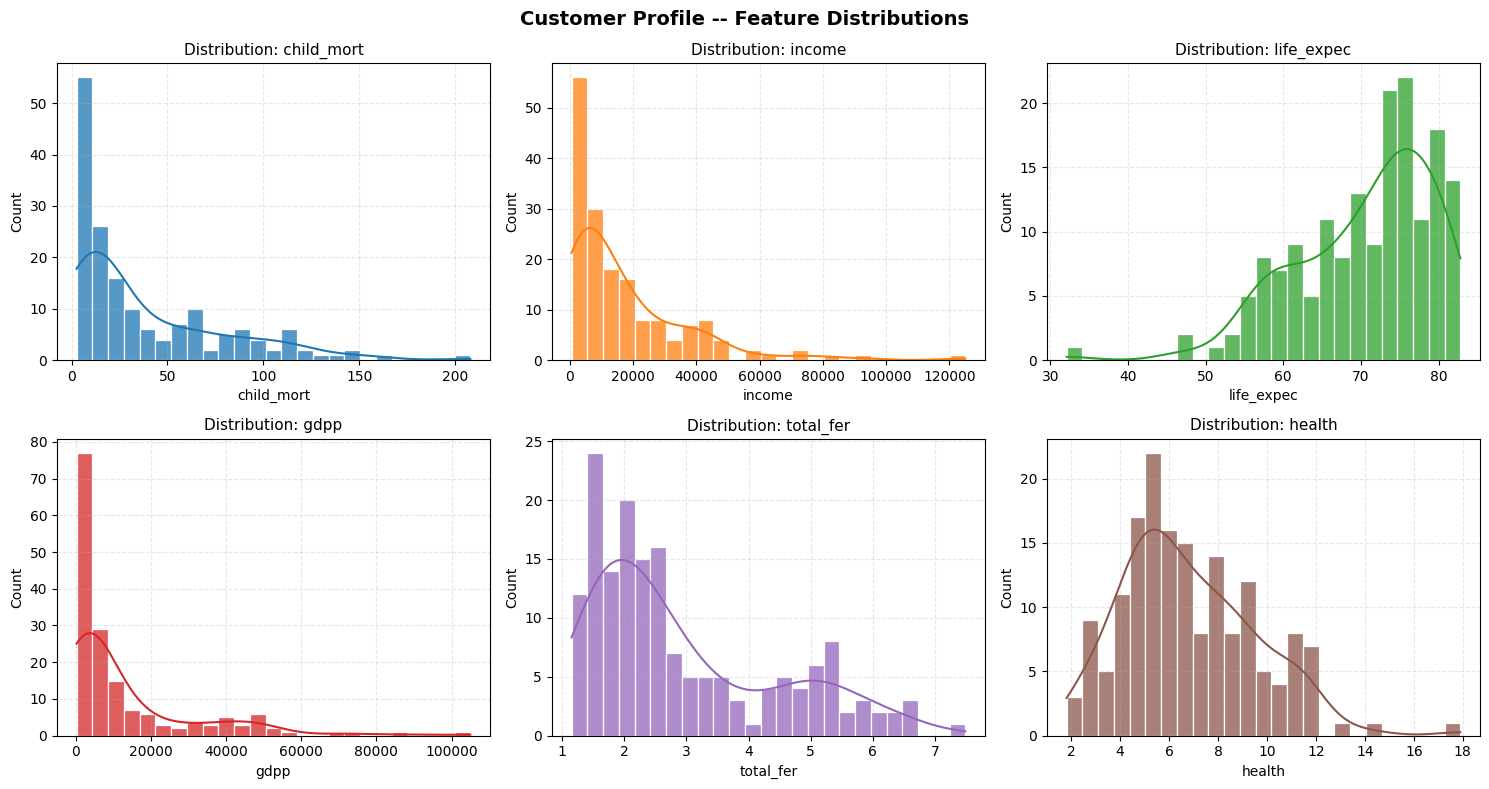

In [12]:
key_features = ['child_mort', 'income', 'life_expec', 'gdpp', 'total_fer', 'health']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for idx, feat in enumerate(key_features):
    sns.histplot(
        df[feat], bins=25, kde=True,
        ax=axes[idx], color=palette[idx],
        edgecolor='white', alpha=0.75
    )
    axes[idx].set_title(f'Distribution: {feat}', fontsize=11)
    axes[idx].set_xlabel(feat)
    axes[idx].set_ylabel('Count')
    axes[idx].grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Customer Profile -- Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# BoxPlots - Outlier Detection

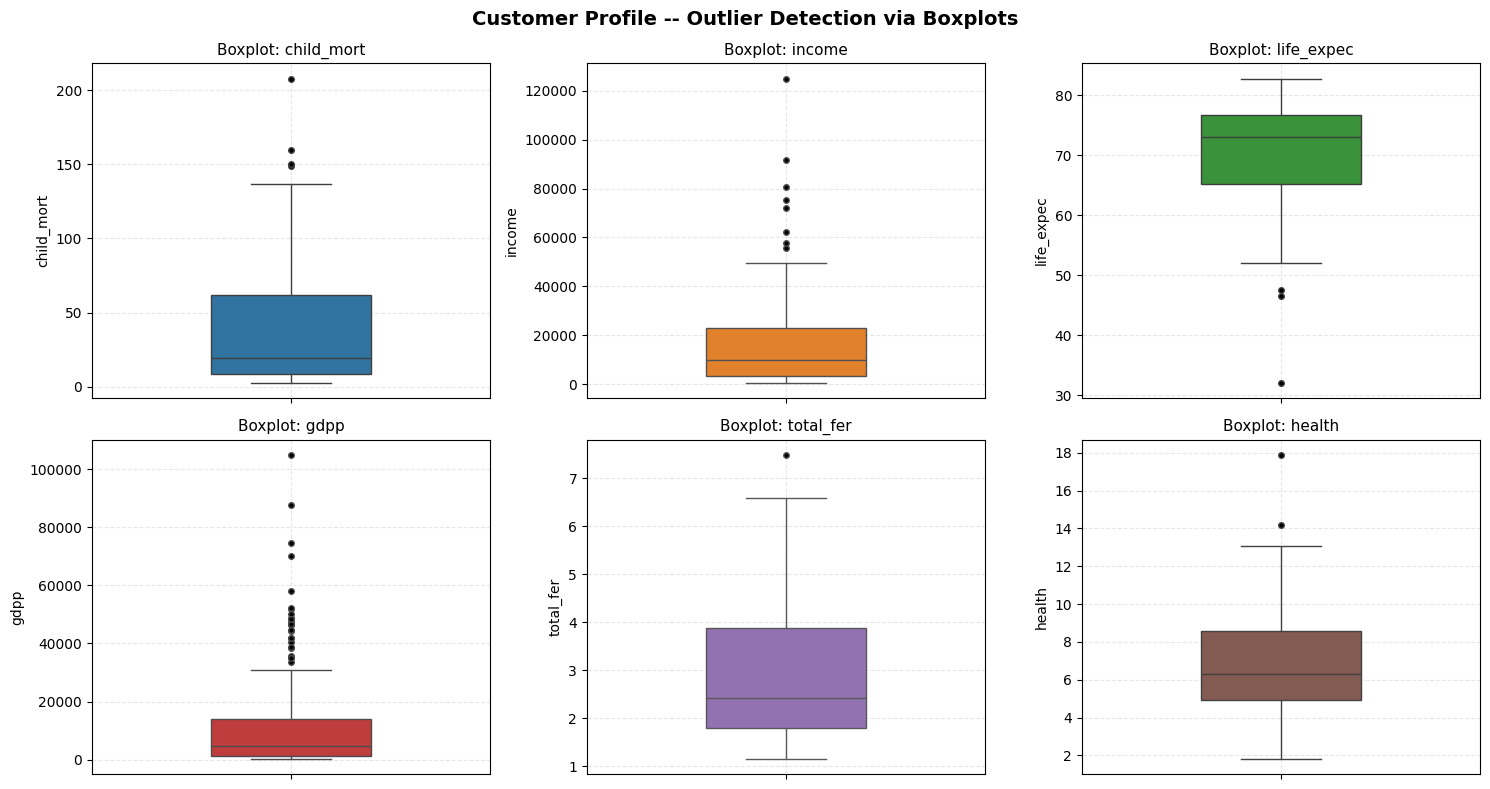

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, feat in enumerate(key_features):
    sns.boxplot(
        y=df[feat], ax=axes[idx],
        color=palette[idx], width=0.4,
        flierprops=dict(marker='o', markerfacecolor='black', markersize=4)
    )
    axes[idx].set_title(f'Boxplot: {feat}', fontsize=11)
    axes[idx].grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Customer Profile -- Outlier Detection via Boxplots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# Data Preprocessing

In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
X_raw = df.drop('country', axis=1)
feature_names = X_raw.columns.tolist()

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Feature matrix shape after scaling: {X_scaled.shape}")
print("\nPer-feature mean (expected ~0):")
for fn, m in zip(feature_names, X_scaled.mean(axis=0).round(4)):
    print(f"  {fn:<15} {m}")
print("\nPer-feature std  (expected ~1):")
for fn, s in zip(feature_names, X_scaled.std(axis=0).round(4)):
    print(f"  {fn:<15} {s}")


Feature matrix shape after scaling: (167, 9)

Per-feature mean (expected ~0):
  child_mort      -0.0
  exports         0.0
  health          0.0
  imports         0.0
  income          -0.0
  inflation       -0.0
  life_expec      0.0
  total_fer       0.0
  gdpp            0.0

Per-feature std  (expected ~1):
  child_mort      1.0
  exports         1.0
  health          1.0
  imports         1.0
  income          1.0
  inflation       1.0
  life_expec      1.0
  total_fer       1.0
  gdpp            1.0


# K-Means Clustering

In [16]:
from sklearn.neighbors import KNeighborsClassifier

In [17]:
from sklearn.cluster import KMeans

In [19]:
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    silhouette_score
)


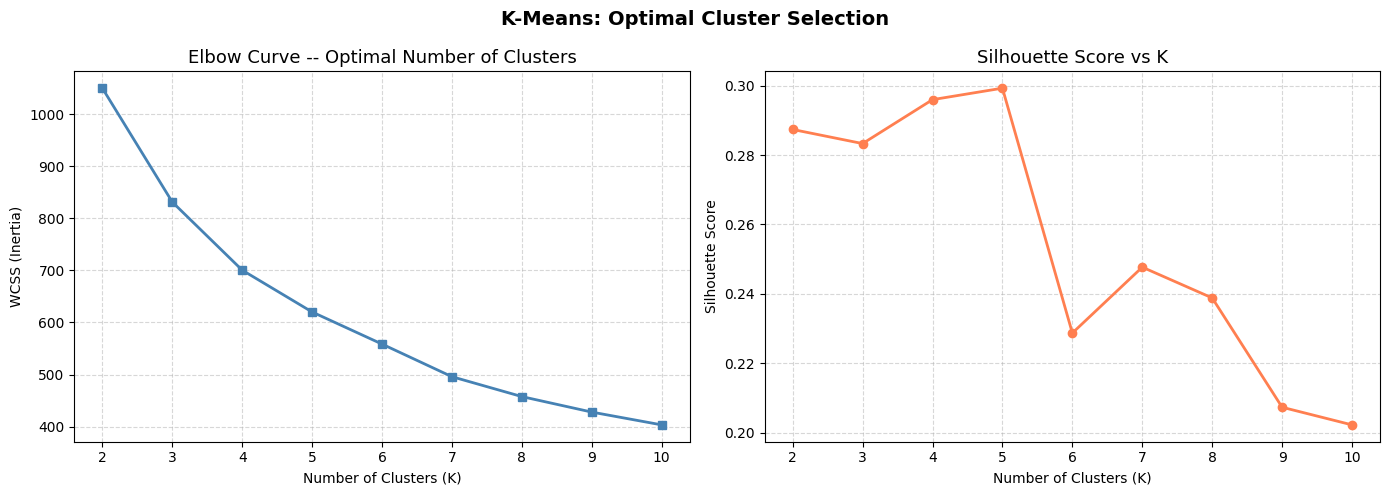

Best K by Silhouette Score -> K = 5  (score = 0.2993)
Silhouette scores across K range: [np.float64(0.2874), np.float64(0.2833), np.float64(0.296), np.float64(0.2993), np.float64(0.2287), np.float64(0.2477), np.float64(0.2388), np.float64(0.2073), np.float64(0.2022)]


In [20]:
wcss_scores = []
sil_scores  = []
k_range     = range(2, 11)

for k in k_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    wcss_scores.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), wcss_scores, marker='s', color='steelblue', linewidth=2)
axes[0].set_title("Elbow Curve -- Optimal Number of Clusters", fontsize=13)
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("WCSS (Inertia)")
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(list(k_range), sil_scores, marker='o', color='coral', linewidth=2)
axes[1].set_title("Silhouette Score vs K", fontsize=13)
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("K-Means: Optimal Cluster Selection", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_k = sil_scores.index(max(sil_scores)) + 2
print(f"Best K by Silhouette Score -> K = {best_k}  (score = {max(sil_scores):.4f})")
print(f"Silhouette scores across K range: {[round(s,4) for s in sil_scores]}")


In [21]:
kmeans     = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

sil_final  = silhouette_score(X_scaled, df['Cluster'])
print(f"K-Means Silhouette Score (K=3): {sil_final:.4f}")
print("\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index().to_string())
print("\nInertia (WCSS):", round(kmeans.inertia_, 2))


K-Means Silhouette Score (K=3): 0.2833

Cluster distribution:
Cluster
0    36
1    47
2    84

Inertia (WCSS): 831.42


In [22]:
cluster_profile = (
    df.groupby('Cluster')
      .mean(numeric_only=True)
      .round(2)
)
print("Mean feature values per customer segment:")
print(cluster_profile.to_string())
print("\nSegment sizes:")
print(df['Cluster'].value_counts().sort_index().to_string())


Mean feature values per customer segment:
         child_mort  exports  health  imports    income  inflation  life_expec  total_fer      gdpp
Cluster                                                                                            
0              5.00    58.74    8.81    51.49  45672.22       2.67       80.13       1.75  42494.44
1             92.96    29.15    6.39    42.32   3942.40      12.02       59.19       5.01   1922.38
2             21.93    40.24    6.20    47.47  12305.60       7.60       72.81       2.31   6486.45

Segment sizes:
Cluster
0    36
1    47
2    84


In [23]:
# Assign labels by inspecting which cluster has the highest mean income
# (Premium = highest income; At-Risk = highest child_mort; Mid-Tier = remainder)
cluster_means = df.groupby('Cluster')['income'].mean()
cluster_mort  = df.groupby('Cluster')['child_mort'].mean()

premium_id  = cluster_means.idxmax()
atrisk_id   = cluster_mort.idxmax()
midtier_id  = [c for c in [0, 1, 2] if c not in [premium_id, atrisk_id]][0]

label_map = {
    premium_id : 'Premium',
    atrisk_id  : 'At-Risk',
    midtier_id : 'Mid-Tier'
}
print("Auto-detected label mapping:", label_map)

df['Customer_Segment'] = df['Cluster'].map(label_map)
print(df[['country', 'Cluster', 'Customer_Segment']].head(10).to_string(index=False))
print("\nSegment Counts:")
print(df['Customer_Segment'].value_counts().to_string())


Auto-detected label mapping: {np.int32(0): 'Premium', np.int32(1): 'At-Risk', 2: 'Mid-Tier'}
            country  Cluster Customer_Segment
        Afghanistan        1          At-Risk
            Albania        2         Mid-Tier
            Algeria        2         Mid-Tier
             Angola        1          At-Risk
Antigua and Barbuda        2         Mid-Tier
          Argentina        2         Mid-Tier
            Armenia        2         Mid-Tier
          Australia        0          Premium
            Austria        0          Premium
         Azerbaijan        2         Mid-Tier

Segment Counts:
Customer_Segment
Mid-Tier    84
At-Risk     47
Premium     36


# Cluster Visualizations

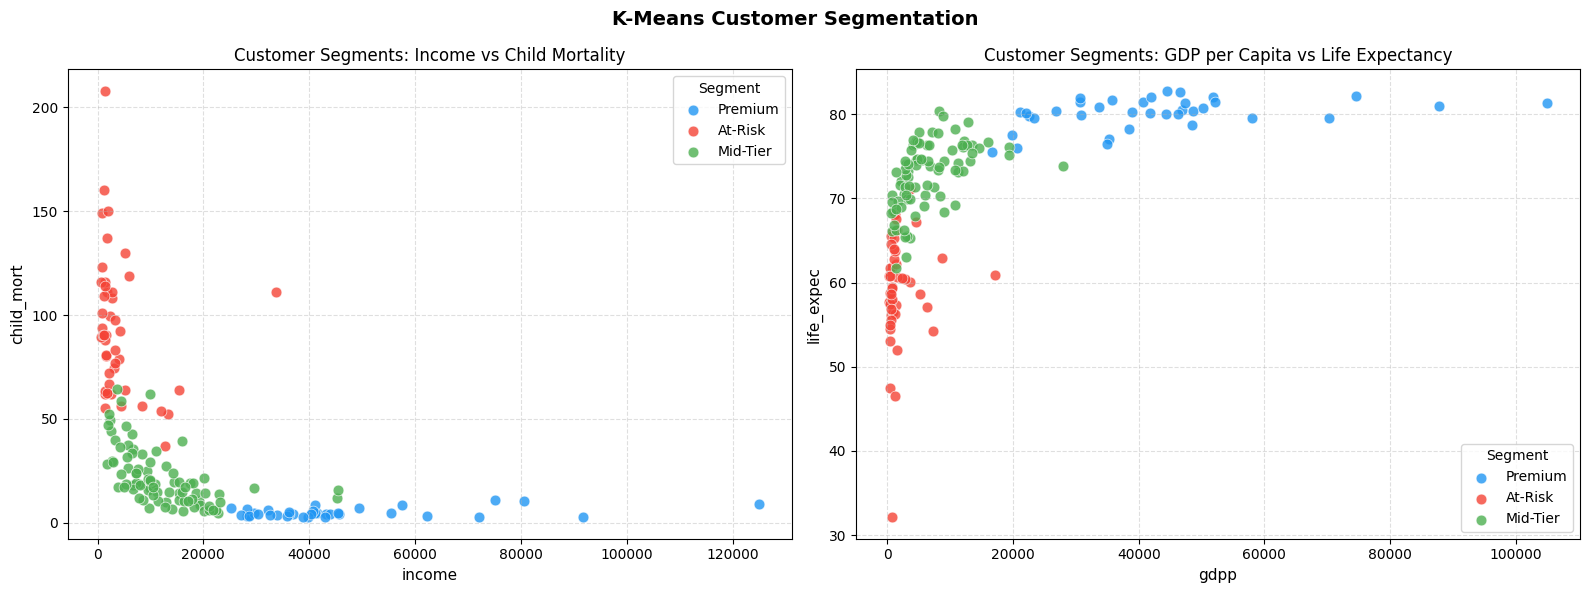

In [24]:
colors     = {0: '#2196F3', 1: '#F44336', 2: '#4CAF50'}
seg_labels = {k: v for k, v in label_map.items()}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_pairs = [
    ('income',   'child_mort', 'Income vs Child Mortality'),
    ('gdpp',     'life_expec', 'GDP per Capita vs Life Expectancy'),
]

for ax, (xcol, ycol, title) in zip(axes, plot_pairs):
    for cid in sorted(df['Cluster'].unique()):
        subset = df[df['Cluster'] == cid]
        ax.scatter(
            subset[xcol], subset[ycol],
            c=colors[cid], label=seg_labels[cid],
            s=60, alpha=0.8, edgecolors='white', linewidths=0.5
        )
    ax.set_xlabel(xcol, fontsize=11)
    ax.set_ylabel(ycol, fontsize=11)
    ax.set_title(f'Customer Segments: {title}', fontsize=12)
    ax.legend(title='Segment')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle("K-Means Customer Segmentation", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# Segment Size - Pie Chart

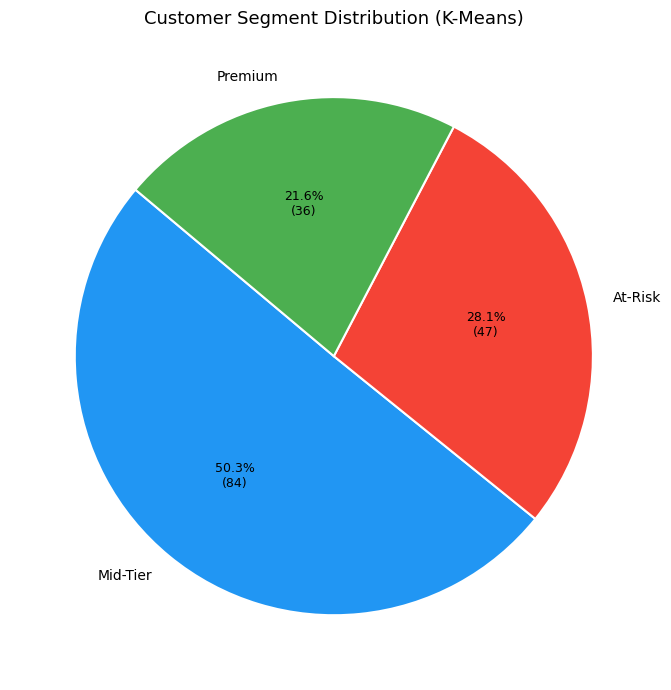

In [25]:
seg_counts = df['Customer_Segment'].value_counts()
seg_colors_pie = ['#2196F3', '#F44336', '#4CAF50']

plt.figure(figsize=(7, 7))
wedges, texts, autotexts = plt.pie(
    seg_counts,
    labels=seg_counts.index,
    autopct=lambda p: f'{p:.1f}%\n({int(round(p*sum(seg_counts)/100))})',
    colors=seg_colors_pie,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontsize(9)
plt.title("Customer Segment Distribution (K-Means)", fontsize=13)
plt.tight_layout()
plt.show()


# PCA 

In [26]:
from sklearn.decomposition import PCA

Explained variance -- PC1: 0.460  PC2: 0.172
Total variance retained  : 0.631  (63.1%)


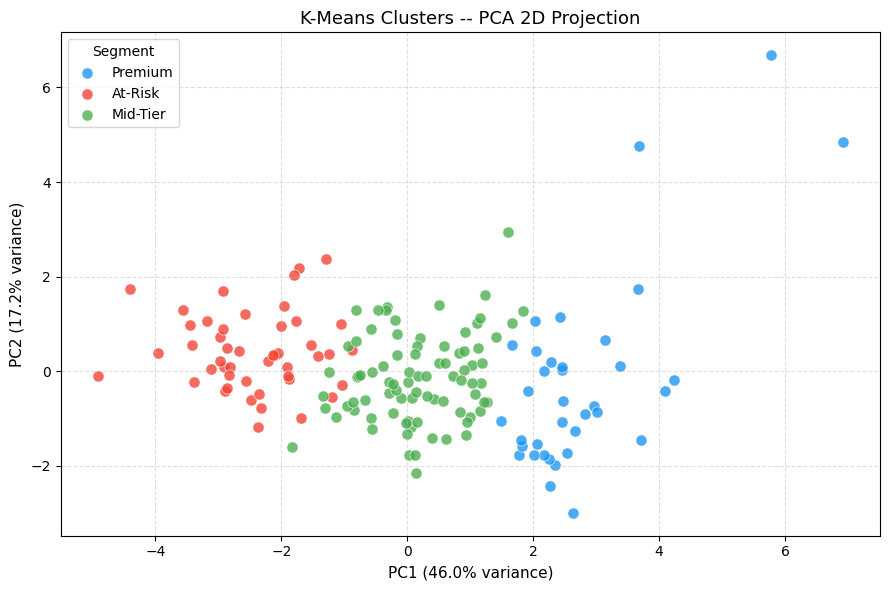

In [28]:
pca        = PCA(n_components=2, random_state=42)
X_pca      = pca.fit_transform(X_scaled)
explained  = pca.explained_variance_ratio_

print(f"Explained variance -- PC1: {explained[0]:.3f}  PC2: {explained[1]:.3f}")
print(f"Total variance retained  : {sum(explained):.3f}  ({sum(explained)*100:.1f}%)")

pca_df = pd.DataFrame({'PC1': X_pca[:, 0], 'PC2': X_pca[:, 1], 'Cluster': df['Cluster']})

plt.figure(figsize=(9, 6))
for cid in sorted(pca_df['Cluster'].unique()):
    sub = pca_df[pca_df['Cluster'] == cid]
    plt.scatter(
        sub['PC1'], sub['PC2'],
        c=colors[cid], label=seg_labels[cid],
        s=65, alpha=0.8, edgecolors='white', linewidths=0.5
    )
plt.xlabel(f'PC1 ({explained[0]*100:.1f}% variance)', fontsize=11)
plt.ylabel(f'PC2 ({explained[1]*100:.1f}% variance)', fontsize=11)
plt.title("K-Means Clusters -- PCA 2D Projection", fontsize=13)
plt.legend(title='Segment')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


# DBSCAN - Density - Based Clustering

In [30]:
from sklearn.cluster import DBSCAN

In [31]:
dbscan_init = DBSCAN(eps=1.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan_init.fit_predict(X_scaled)

n_init_clusters = len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'].values else 0)
n_init_noise    = (df['DBSCAN_Cluster'] == -1).sum()
print("Initial DBSCAN cluster distribution:")
print(df['DBSCAN_Cluster'].value_counts().sort_index().to_string())
print(f"\nClusters found: {n_init_clusters}  |  Noise points: {n_init_noise}")


Initial DBSCAN cluster distribution:
DBSCAN_Cluster
-1     30
 0    137

Clusters found: 1  |  Noise points: 30


In [32]:
print("Tuning eps (min_samples=5 fixed):")
print("-" * 58)
print(f"{'eps':>6}  {'Clusters':>9}  {'Noise':>7}  {'Silhouette':>12}")
print("-" * 58)
for eps_val in [0.8, 1.0, 1.2, 1.4, 1.6]:
    db  = DBSCAN(eps=eps_val, min_samples=5)
    lbs = db.fit_predict(X_scaled)
    n_c = len(set(lbs)) - (1 if -1 in lbs else 0)
    n_n = list(lbs).count(-1)
    sil = silhouette_score(X_scaled, lbs) if n_c > 1 else float('nan')
    print(f"  {eps_val:>4}  {n_c:>9}  {n_n:>7}  {sil:>12.4f}")


Tuning eps (min_samples=5 fixed):
----------------------------------------------------------
   eps   Clusters    Noise    Silhouette
----------------------------------------------------------
   0.8          3      146       -0.2454
   1.0          3       94       -0.0248
   1.2          3       53        0.1484
   1.4          1       40           nan
   1.6          1       28           nan


In [33]:
print("Tuning min_samples (eps=1.2 fixed):")
print("-" * 52)
print(f"{'min_samples':>12}  {'Clusters':>9}  {'Noise':>7}")
print("-" * 52)
for ms in [3, 4, 5, 6]:
    db  = DBSCAN(eps=1.2, min_samples=ms)
    lbs = db.fit_predict(X_scaled)
    n_c = len(set(lbs)) - (1 if -1 in lbs else 0)
    n_n = list(lbs).count(-1)
    print(f"  {ms:>12}  {n_c:>9}  {n_n:>7}")


Tuning min_samples (eps=1.2 fixed):
----------------------------------------------------
 min_samples   Clusters    Noise
----------------------------------------------------
             3          4       41
             4          3       50
             5          3       53
             6          3       63


In [34]:
dbscan_final        = DBSCAN(eps=1.2, min_samples=3)
df['DBSCAN_Cluster'] = dbscan_final.fit_predict(X_scaled)

n_clusters = len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'].values else 0)
n_noise    = (df['DBSCAN_Cluster'] == -1).sum()

print(f"DBSCAN Clusters Detected : {n_clusters}")
print(f"Noise / Outlier Customers: {n_noise}  ({n_noise/len(df)*100:.1f}%)")
print("\nFinal cluster distribution:")
print(df['DBSCAN_Cluster'].value_counts().sort_index().to_string())

non_noise_mask = df['DBSCAN_Cluster'] != -1
if n_clusters > 1:
    sil_db = silhouette_score(X_scaled[non_noise_mask], df.loc[non_noise_mask, 'DBSCAN_Cluster'])
    print(f"\nDBSCAN Silhouette Score (non-noise points): {sil_db:.4f}")


DBSCAN Clusters Detected : 4
Noise / Outlier Customers: 41  (24.6%)

Final cluster distribution:
DBSCAN_Cluster
-1    41
 0    25
 1    78
 2    19
 3     4

DBSCAN Silhouette Score (non-noise points): 0.2984


# K-Means vs DBSCAN 

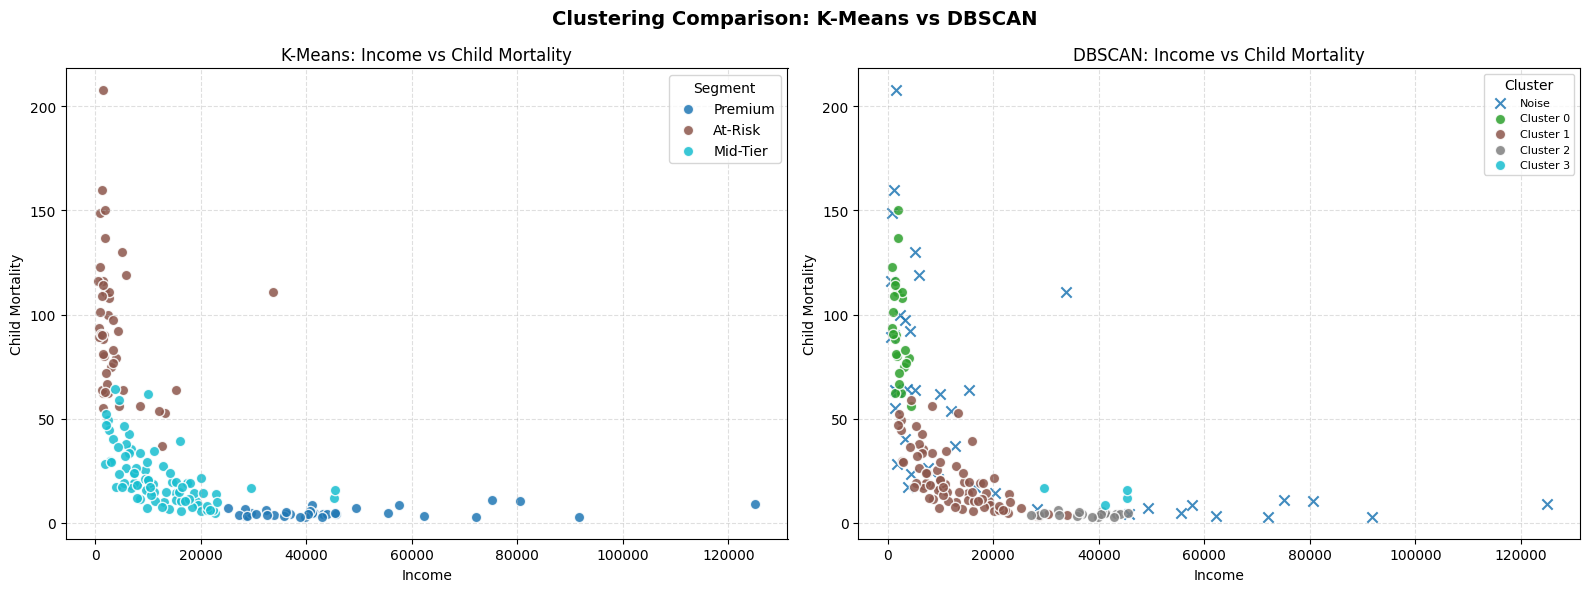

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means plot
km_cmap = plt.cm.get_cmap('tab10', 3)
for cid in sorted(df['Cluster'].unique()):
    sub = df[df['Cluster'] == cid]
    axes[0].scatter(
        sub['income'], sub['child_mort'],
        color=km_cmap(cid), label=seg_labels[cid],
        s=55, alpha=0.85, edgecolors='white'
    )
axes[0].set_title("K-Means: Income vs Child Mortality", fontsize=12)
axes[0].set_xlabel("Income")
axes[0].set_ylabel("Child Mortality")
axes[0].legend(title='Segment')
axes[0].grid(True, linestyle='--', alpha=0.4)

# DBSCAN plot
db_ids  = sorted(df['DBSCAN_Cluster'].unique())
db_cmap = plt.cm.get_cmap('tab10', len(db_ids))
for i, cid in enumerate(db_ids):
    sub = df[df['DBSCAN_Cluster'] == cid]
    lbl = 'Noise' if cid == -1 else f'Cluster {cid}'
    axes[1].scatter(
        sub['income'], sub['child_mort'],
        color=db_cmap(i), label=lbl, s=55, alpha=0.85,
        edgecolors='white', marker='x' if cid == -1 else 'o'
    )
axes[1].set_title("DBSCAN: Income vs Child Mortality", fontsize=12)
axes[1].set_xlabel("Income")
axes[1].set_ylabel("Child Mortality")
axes[1].legend(title='Cluster', fontsize=8)
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.suptitle("Clustering Comparison: K-Means vs DBSCAN", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# Classification - Predicting Customer Segments

In [36]:
from sklearn.model_selection import train_test_split

In [40]:
X_cls = df.drop(['country', 'Cluster', 'Customer_Segment', 'DBSCAN_Cluster'], axis=1)
y_cls = df['Cluster']

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")
print(f"Features  : {X_train.shape[1]}")
print(f"\nClass distribution (train):\n{y_train.value_counts().sort_index().to_string()}")
print(f"\nClass distribution (test):\n{y_test.value_counts().sort_index().to_string()}")


Train size: 133  |  Test size: 34
Features  : 9

Class distribution (train):
Cluster
0    29
1    37
2    67

Class distribution (test):
Cluster
0     7
1    10
2    17


In [41]:
baseline_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=6, random_state=42),
    'KNN (k=5)'          : KNeighborsClassifier(n_neighbors=5, metric='euclidean')
}

baseline_results = {}
print("Baseline Model Performance (5-Fold Cross-Validation):")
print("-" * 58)
print(f"{'Model':<28}  {'CV Mean':>8}  {'CV Std':>8}")
print("-" * 58)
for name, model in baseline_models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', model)])
    cv   = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    baseline_results[name] = cv.mean()
    print(f"  {name:<26}  {cv.mean():>8.4f}  {cv.std():>8.4f}")


Baseline Model Performance (5-Fold Cross-Validation):
----------------------------------------------------------
Model                          CV Mean    CV Std
----------------------------------------------------------
  Logistic Regression           0.9550    0.0283
  Decision Tree                 0.9097    0.0188
  KNN (k=5)                     0.9328    0.0428


# Ensemble Learning - Random Forest Classifier

In [42]:
rf_param_grid = {
    'n_estimators'     : [100, 150, 200],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2]
}

rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
rf_gs.fit(X_train, y_train)

rf_best   = rf_gs.best_estimator_
y_pred_rf = rf_best.predict(X_test)
rf_acc    = accuracy_score(y_test, y_pred_rf)

print("Best Hyperparameters:", rf_gs.best_params_)
print(f"Best CV Score       : {rf_gs.best_score_:.4f}")
print(f"\nRandom Forest Test Accuracy: {rf_acc:.4f}  ({rf_acc*100:.2f}%)")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_rf,
      target_names=['Premium', 'At-Risk', 'Mid-Tier']))


Best Hyperparameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score       : 0.9396

Random Forest Test Accuracy: 1.0000  (100.00%)

Detailed Classification Report:
              precision    recall  f1-score   support

     Premium       1.00      1.00      1.00         7
     At-Risk       1.00      1.00      1.00        10
    Mid-Tier       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



Random Forest 5-Fold CV Accuracy: 0.9578 +/- 0.0310
Per-fold scores: [np.float64(0.9706), np.float64(1.0), np.float64(0.9394), np.float64(0.9091), np.float64(0.9697)]


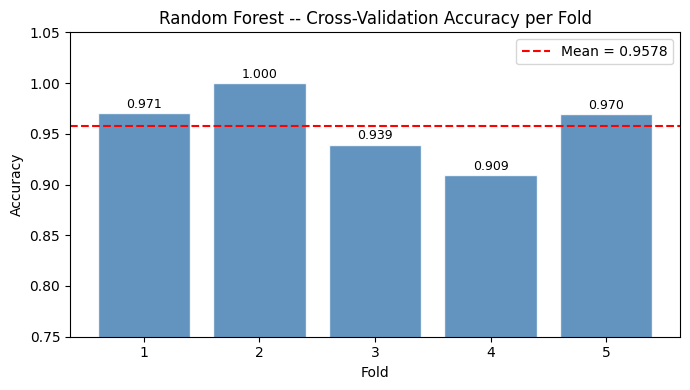

In [43]:
rf_cv = cross_val_score(rf_best, X_cls, y_cls, cv=5, scoring='accuracy')
print(f"Random Forest 5-Fold CV Accuracy: {rf_cv.mean():.4f} +/- {rf_cv.std():.4f}")
print(f"Per-fold scores: {[round(v, 4) for v in rf_cv]}")

plt.figure(figsize=(7, 4))
bars = plt.bar(range(1, 6), rf_cv, color='steelblue', alpha=0.85, edgecolor='white')
plt.axhline(rf_cv.mean(), color='red', linestyle='--', linewidth=1.5,
            label=f'Mean = {rf_cv.mean():.4f}')
for b, v in zip(bars, rf_cv):
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
             f'{v:.3f}', ha='center', fontsize=9)
plt.title("Random Forest -- Cross-Validation Accuracy per Fold", fontsize=12)
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.ylim(0.75, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


# Ensemble Leaning - XGBoost Classifier

In [44]:
xgb_param_grid = {
    'n_estimators' : [100, 150],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth'    : [3, 5, 7],
    'subsample'    : [0.8, 1.0]
}

xgb_gs = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False),
    xgb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
xgb_gs.fit(X_train, y_train)

xgb_best   = xgb_gs.best_estimator_
y_pred_xgb = xgb_best.predict(X_test)
xgb_acc    = accuracy_score(y_test, y_pred_xgb)

print("Best Hyperparameters:", xgb_gs.best_params_)
print(f"Best CV Score       : {xgb_gs.best_score_:.4f}")
print(f"\nXGBoost Test Accuracy: {xgb_acc:.4f}  ({xgb_acc*100:.2f}%)")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_xgb,
      target_names=['Premium', 'At-Risk', 'Mid-Tier']))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:38:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:38:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:38:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:38:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Best Hyperparameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV Score       : 0.9470

XGBoost Test Accuracy: 0.9706  (97.06%)

Detailed Classification Report:
              precision    recall  f1-score   support

     Premium       1.00      1.00      1.00         7
     At-Risk       1.00      0.90      0.95        10
    Mid-Tier       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



XGBoost 5-Fold CV Accuracy: 0.9579 +/- 0.0240
Per-fold scores: [np.float64(0.9412), np.float64(1.0), np.float64(0.9394), np.float64(0.9394), np.float64(0.9697)]


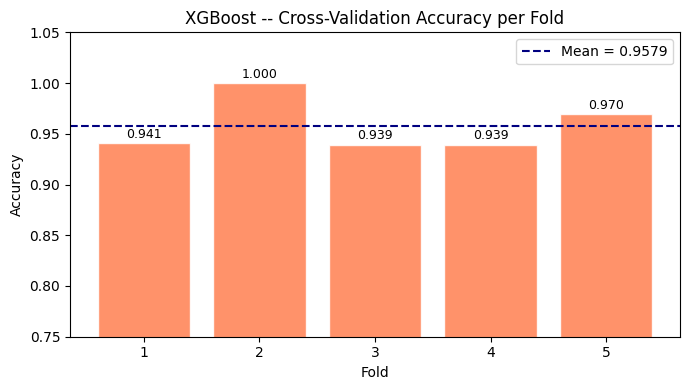

In [45]:
xgb_cv = cross_val_score(xgb_best, X_cls, y_cls, cv=5, scoring='accuracy')
print(f"XGBoost 5-Fold CV Accuracy: {xgb_cv.mean():.4f} +/- {xgb_cv.std():.4f}")
print(f"Per-fold scores: {[round(v, 4) for v in xgb_cv]}")

plt.figure(figsize=(7, 4))
bars = plt.bar(range(1, 6), xgb_cv, color='coral', alpha=0.85, edgecolor='white')
plt.axhline(xgb_cv.mean(), color='navy', linestyle='--', linewidth=1.5,
            label=f'Mean = {xgb_cv.mean():.4f}')
for b, v in zip(bars, xgb_cv):
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
             f'{v:.3f}', ha='center', fontsize=9)
plt.title("XGBoost -- Cross-Validation Accuracy per Fold", fontsize=12)
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.ylim(0.75, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


   MODEL PERFORMANCE SUMMARY
                Model  Accuracy
Random Forest (tuned)  1.000000
      XGBoost (tuned)  0.970588
  Logistic Regression  0.954986
            KNN (k=5)  0.932764
        Decision Tree  0.909687


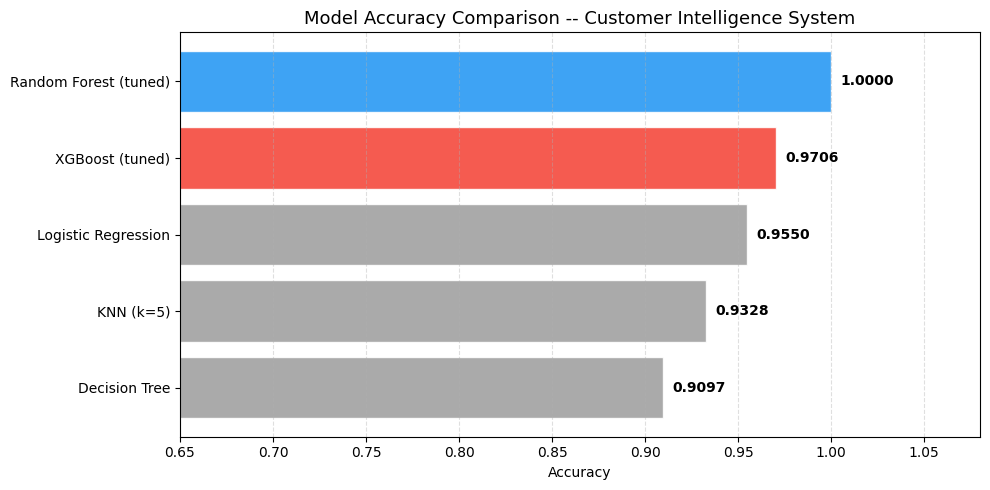


Best Performing Model: Random Forest (tuned)  (1.0000)


In [47]:
all_results = {
    **baseline_results,
    'Random Forest (tuned)': rf_acc,
    'XGBoost (tuned)'      : xgb_acc
}

results_df = (
    pd.DataFrame(list(all_results.items()), columns=['Model', 'Accuracy'])
      .sort_values('Accuracy', ascending=False)
      .reset_index(drop=True)
)

print("=" * 45)
print("   MODEL PERFORMANCE SUMMARY")
print("=" * 45)
print(results_df.to_string(index=False))

bar_colors = [
    '#2196F3' if 'Random Forest' in m
    else '#F44336' if 'XGBoost' in m
    else '#9E9E9E'
    for m in results_df['Model']
]

plt.figure(figsize=(10, 5))
bars = plt.barh(results_df['Model'], results_df['Accuracy'],
                color=bar_colors, alpha=0.87, edgecolor='white')
plt.xlim(0.65, 1.08)
for bar, val in zip(bars, results_df['Accuracy']):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
plt.title("Model Accuracy Comparison -- Customer Intelligence System", fontsize=13)
plt.xlabel("Accuracy")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

best_model = results_df.iloc[0]['Model']
print(f"\nBest Performing Model: {best_model}  ({results_df.iloc[0]['Accuracy']:.4f})")


# Confusion Matrices - Random Forest vs XGBoost

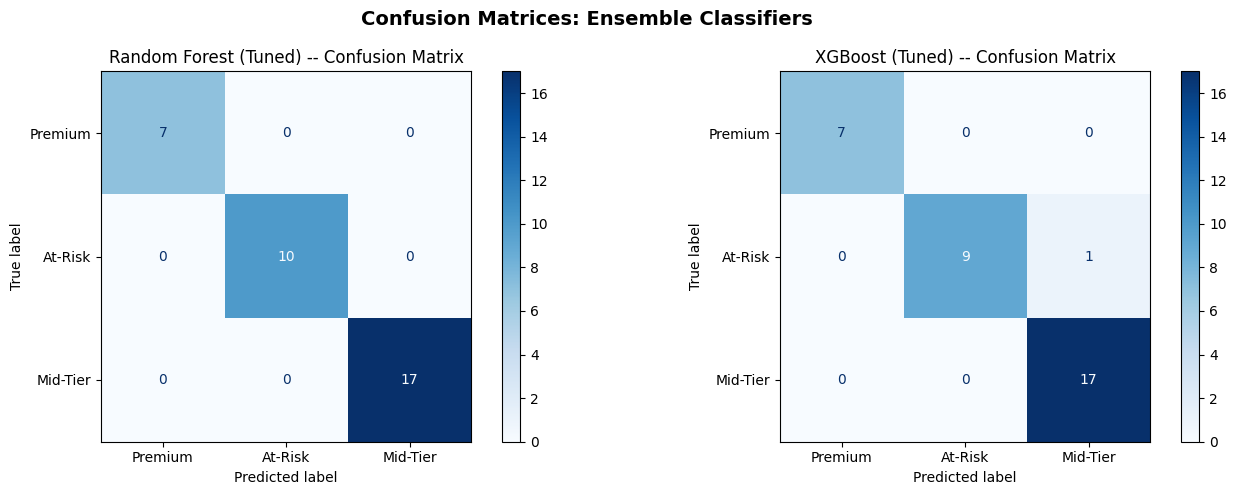

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
seg_names = ['Premium', 'At-Risk', 'Mid-Tier']

for ax, (preds, title) in zip(axes, [
    (y_pred_rf,  'Random Forest (Tuned)'),
    (y_pred_xgb, 'XGBoost (Tuned)')
]):
    cm   = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=seg_names)
    disp.plot(ax=ax, colorbar=True, cmap='Blues')
    ax.set_title(f'{title} -- Confusion Matrix', fontsize=12)

plt.suptitle("Confusion Matrices: Ensemble Classifiers", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# Classification Reports 

In [49]:
from sklearn.metrics import classification_report

seg_names = ['Premium', 'At-Risk', 'Mid-Tier']

for model_name, preds in [('Random Forest', y_pred_rf), ('XGBoost', y_pred_xgb)]:
    print(f"\n{'='*45}")
    print(f"  {model_name} -- Detailed Report")
    print(f"{'='*45}")
    print(classification_report(y_test, preds, target_names=seg_names))



  Random Forest -- Detailed Report
              precision    recall  f1-score   support

     Premium       1.00      1.00      1.00         7
     At-Risk       1.00      1.00      1.00        10
    Mid-Tier       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34


  XGBoost -- Detailed Report
              precision    recall  f1-score   support

     Premium       1.00      1.00      1.00         7
     At-Risk       1.00      0.90      0.95        10
    Mid-Tier       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



In [50]:
feat_imp_df = pd.DataFrame({
    'Feature'       : X_cls.columns,
    'RF Importance' : rf_best.feature_importances_,
    'XGB Importance': xgb_best.feature_importances_
}).sort_values('RF Importance', ascending=False).reset_index(drop=True)

print("Feature Importance Rankings (sorted by Random Forest):")
print(feat_imp_df.round(4).to_string(index=False))

top_rf  = feat_imp_df.iloc[0]['Feature']
top_xgb = feat_imp_df.sort_values('XGB Importance', ascending=False).iloc[0]['Feature']
print(f"\nTop feature (RF)    : {top_rf}")
print(f"Top feature (XGBoost): {top_xgb}")


Feature Importance Rankings (sorted by Random Forest):
   Feature  RF Importance  XGB Importance
child_mort         0.2619          0.2066
      gdpp         0.2021          0.3532
 total_fer         0.1659          0.0839
life_expec         0.1563          0.0716
    income         0.1462          0.2277
    health         0.0305          0.0243
 inflation         0.0148          0.0128
   imports         0.0126          0.0105
   exports         0.0096          0.0094

Top feature (RF)    : child_mort
Top feature (XGBoost): gdpp


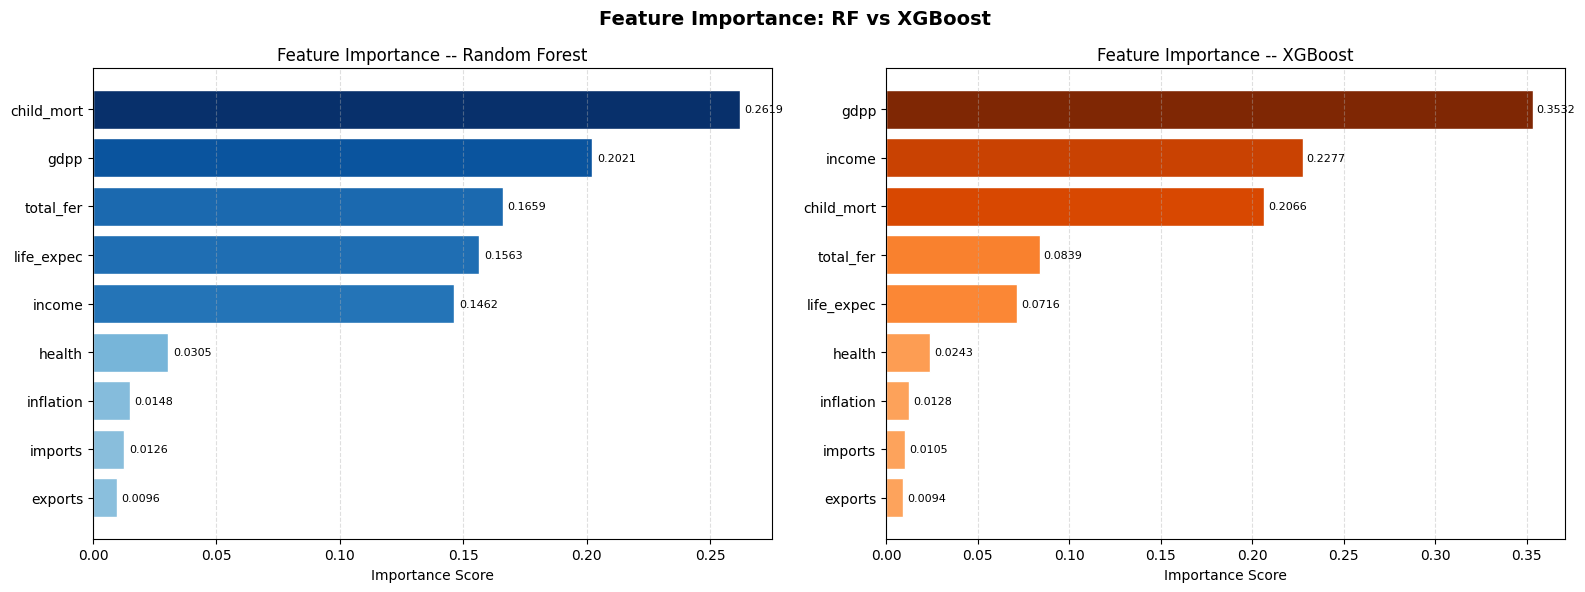

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (col, title, cmap) in zip(axes, [
    ('RF Importance',  'Random Forest', plt.cm.Blues),
    ('XGB Importance', 'XGBoost',       plt.cm.Oranges)
]):
    sf  = feat_imp_df.sort_values(col, ascending=True)
    clr = cmap([0.4 + 0.6 * v / sf[col].max() for v in sf[col]])
    bars = ax.barh(sf['Feature'], sf[col], color=clr, edgecolor='white')
    for b, v in zip(bars, sf[col]):
        ax.text(v + 0.002, b.get_y() + b.get_height()/2,
                f'{v:.4f}', va='center', fontsize=8)
    ax.set_title(f'Feature Importance -- {title}', fontsize=12)
    ax.set_xlabel('Importance Score')
    ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.suptitle("Feature Importance: RF vs XGBoost", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# Customer Segment Isights

In [52]:
print("=" * 65)
for cid, label in [(premium_id, 'Premium'), (midtier_id, 'Mid-Tier'), (atrisk_id, 'At-Risk')]:
    subset = (
        df[df['Cluster'] == cid]
          [['country', 'income', 'gdpp', 'life_expec', 'child_mort']]
          .sort_values('gdpp', ascending=False)
          .head(5)
    )
    print(f"\n  {label} Customers -- Top 5 by GDP per Capita:")
    print(subset.to_string(index=False))
    print("-" * 65)



  Premium Customers -- Top 5 by GDP per Capita:
    country  income   gdpp  life_expec  child_mort
 Luxembourg   91700 105000        81.3         2.8
     Norway   62300  87800        81.0         3.2
Switzerland   55500  74600        82.2         4.5
      Qatar  125000  70300        79.5         9.0
    Denmark   44000  58000        79.5         4.1
-----------------------------------------------------------------

  Mid-Tier Customers -- Top 5 by GDP per Capita:
     country  income  gdpp  life_expec  child_mort
     Bahamas   22900 28000        73.8        13.8
Saudi Arabia   45400 19300        75.1        15.7
        Oman   45300 19300        76.1        11.7
    Barbados   15300 16000        76.7        14.2
     Estonia   22700 14600        76.0         4.5
-----------------------------------------------------------------

  At-Risk Customers -- Top 5 by GDP per Capita:
          country  income  gdpp  life_expec  child_mort
Equatorial Guinea   33700 17100        60.9       11

# Cluster Radar Chart - Segment Profiles

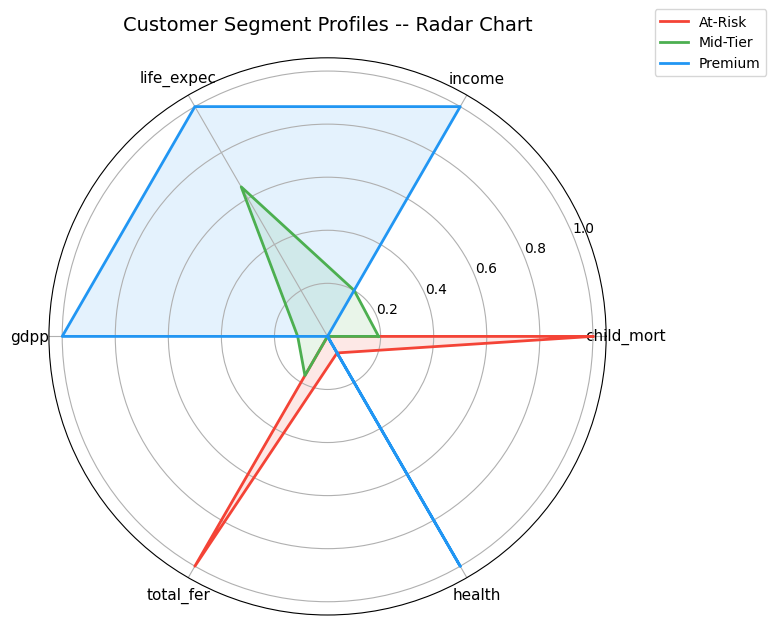

In [54]:
import numpy as np

features_radar = ['child_mort', 'income', 'life_expec', 'gdpp', 'total_fer', 'health']
profile        = df.groupby('Customer_Segment')[features_radar].mean()

# Normalise 0-1 per feature for a fair radar shape
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())

N      = len(features_radar)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

seg_colors_radar = {'Premium': '#2196F3', 'Mid-Tier': '#4CAF50', 'At-Risk': '#F44336'}

for seg, row in profile_norm.iterrows():
    values  = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, linewidth=2, label=seg, color=seg_colors_radar.get(seg, 'gray'))
    ax.fill(angles, values, alpha=0.12, color=seg_colors_radar.get(seg, 'gray'))

ax.set_xticks(angles[:-1])
ax.set_xticklabels(features_radar, fontsize=11)
ax.set_title("Customer Segment Profiles -- Radar Chart", fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()


# Clustering Metrics Summary

In [55]:
print("=" * 55)
print("  CLUSTERING EVALUATION SUMMARY")
print("=" * 55)

km_sil = silhouette_score(X_scaled, df['Cluster'])
print(f"  K-Means  (K=3)  Silhouette Score : {km_sil:.4f}")

non_noise_mask2 = df['DBSCAN_Cluster'] != -1
if non_noise_mask2.sum() > 0 and len(df.loc[non_noise_mask2, 'DBSCAN_Cluster'].unique()) > 1:
    db_sil = silhouette_score(
        X_scaled[non_noise_mask2],
        df.loc[non_noise_mask2, 'DBSCAN_Cluster']
    )
    print(f"  DBSCAN          Silhouette Score : {db_sil:.4f}  (non-noise only)")
    print(f"  DBSCAN Outlier / Noise count     : {(~non_noise_mask2).sum()}")

print()
print("  Silhouette Score ranges from -1 (poor separation) to +1 (perfect).")
print("  Scores above 0.5 indicate well-defined, meaningful clusters.")
print(f"\n  K-Means interpretation: {'Good' if km_sil > 0.5 else 'Moderate'} cluster quality.")


  CLUSTERING EVALUATION SUMMARY
  K-Means  (K=3)  Silhouette Score : 0.2833
  DBSCAN          Silhouette Score : 0.2984  (non-noise only)
  DBSCAN Outlier / Noise count     : 41

  Silhouette Score ranges from -1 (poor separation) to +1 (perfect).
  Scores above 0.5 indicate well-defined, meaningful clusters.

  K-Means interpretation: Moderate cluster quality.
